phase-1 loading datasets and understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('CustomerChurn.csv')
print('shape :', df.shape)
print('head :', df.head())

shape : (7043, 21)
head :    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
#dropped columns
drop_columns = ['customerID']

#target coulmn
target_column = 'Churn'

#numrical columns
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

#categorical columns
categorical_columns = ["MultipleLines", "InternetService", "OnlineSecurity",
"OnlineBackup", "DeviceProtection", "TechSupport",
"StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

#already numrical columns
already_numerical_columns = ['SeniorCitizen']

phase-2 data cleaning

In [7]:
df.drop(columns=["customerID"], inplace = True)
print("CustomerId dropped")
print("New Shape :",df.shape)

CustomerId dropped
New Shape : (7043, 20)


In [8]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"], errors='coerce') #converting TotalCharges column to numeric
print("Null values in TotalCharges Column:", df["TotalCharges"].isnull().sum())

Null values in TotalCharges Column: 11


In [9]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True) #filling null values with median
print("null values after filling Null Values:", df["TotalCharges"].isnull().sum())

null values after filling Null Values: 0


In [10]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({ 1:"Yes", 0: "No"})

In [12]:
#final check for null values
print("Null values in the dataset:\n", df.isnull().sum())

Null values in the dataset:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


phase-3 EDA

Chart-1 Overall churn distribution

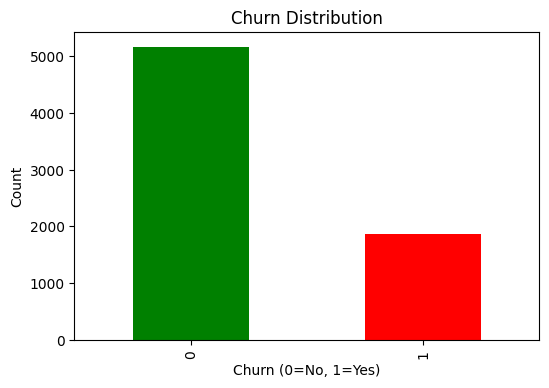

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
df["Churn"].value_counts().plot(kind='bar', color=['green', 'red'],ax=ax)
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn (0=No, 1=Yes)")
ax.set_ylabel("Count")
plt.show()

chart-2 Churn By Contract Type

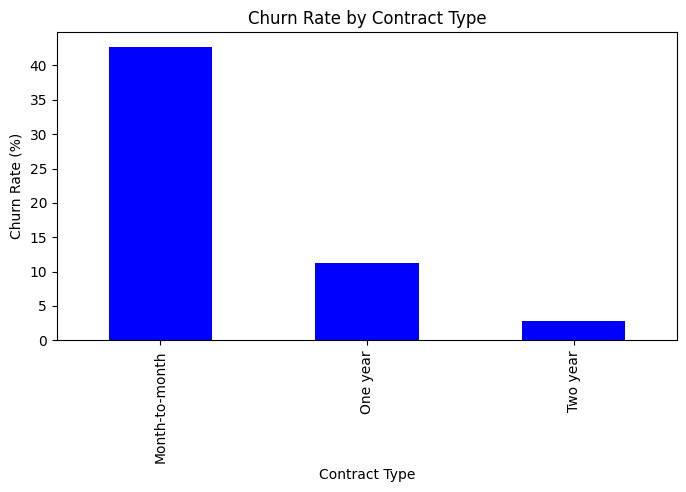

In [14]:
fig,ax = plt.subplots(figsize=(8,4))
churn_by_contract = df.groupby("Contract")["Churn"].mean()*100
churn_by_contract.sort_values(ascending=False).plot(kind='bar',color='blue' ,ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
plt.show()


chart-3 churn by tenure

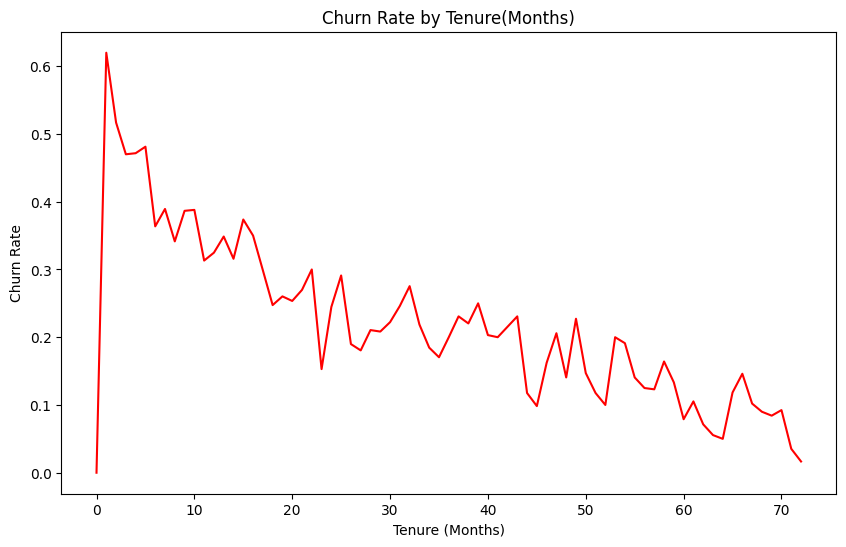

In [15]:
fig,ax = plt.subplots(figsize=(10,6))
df.groupby("tenure")["Churn"].mean().plot(ax=ax,color='Red')
ax.set_title("Churn Rate by Tenure(Months)")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Churn Rate")
plt.show()

chart-4 Monthly charges distribution

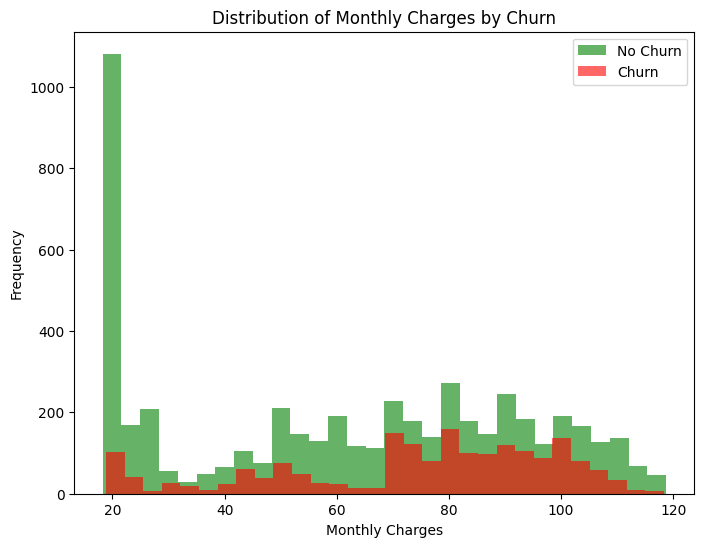

In [16]:
fig,ax =plt.subplots(figsize=(8,6))
for label, group in df.groupby("Churn"):
    color = 'red' if label == 1 else 'green'
    group["MonthlyCharges"].plot(kind="hist", bins=30, alpha=0.6, ax=ax, color=color)
ax.set_title("Distribution of Monthly Charges by Churn")
ax.set_xlabel("Monthly Charges")
ax.legend(["No Churn","Churn"])
plt.show()

chart-5 churn by internet service

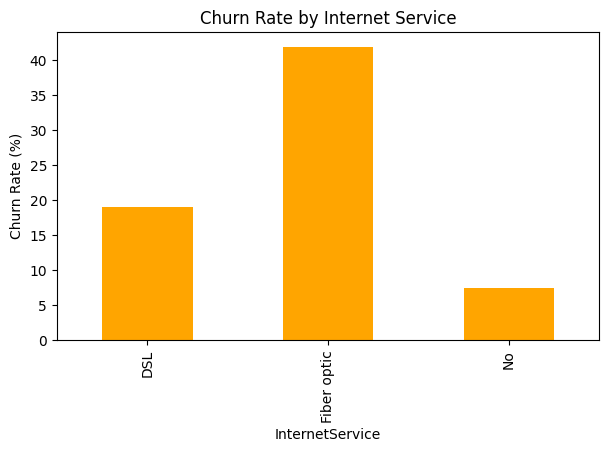

In [17]:
fig,ax= plt.subplots(figsize=(7,4))
churn_internet=df.groupby("InternetService")["Churn"].mean()*100
churn_internet.plot(kind='bar',color='orange',ax=ax)
ax.set_title("Churn Rate by Internet Service")
ax.set_ylabel("Churn Rate (%)")
plt.show()

chart-6 correlation heatmap

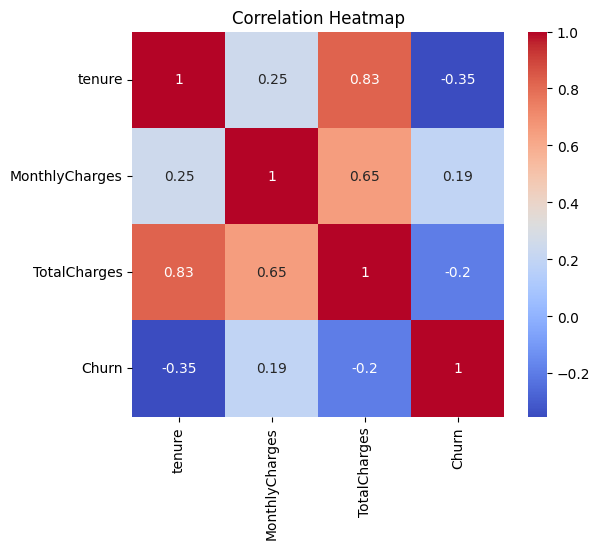

In [18]:
numerical_df=df[["tenure","MonthlyCharges","TotalCharges","Churn"]]
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(numerical_df.corr(),annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

Phase-4 Data Preprocessing

In [19]:
from sklearn.preprocessing import LabelEncoder

binary_columns = ["gender", "Partner","Dependents","PhoneService",
                  "PaperlessBilling","SeniorCitizen"]

le = LabelEncoder()
for col in binary_columns:
    df[col]=le.fit_transform(df[col])

print("Label Encoding completed for binary columns.")
print(df[binary_columns].head())

Label Encoding completed for binary columns.
   gender  Partner  Dependents  PhoneService  PaperlessBilling  SeniorCitizen
0       0        1           0             0                 1              0
1       1        0           0             1                 0              0
2       1        0           0             1                 1              0
3       1        0           0             0                 0              0
4       0        0           0             1                 1              0


In [20]:
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
              "OnlineBackup","DeviceProtection","TechSupport",
              "StreamingTV", "StreamingMovies","Contract","PaymentMethod"]

df = pd.get_dummies(df,columns=multi_cols,drop_first=True)

print("one hot encoding done")
print("New shape", df.shape)
print("New Columns:",df.columns.to_list())

one hot encoding done
New shape (7043, 31)
New Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [21]:
x= df.drop(columns=["Churn"])
y=df["Churn"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)
print("Features columns:", x.columns.to_list())

Features shape: (7043, 30)
Target shape: (7043,)
Features columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("train size:", x_train.shape)
print("test size:", x_test.shape)
print("train churn rate:",y_train.mean().round(3))
print("test churn rate:",y_test.mean().round(3))

train size: (5634, 30)
test size: (1409, 30)
train churn rate: 0.265
test churn rate: 0.265


In [23]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler=StandardScaler()

numerical_cols=["tenure","MonthlyCharges","TotalCharges"]

x_train[numerical_cols]=scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]=scaler.transform(x_test[numerical_cols])

joblib.dump(scaler,"./models/scaler.pkl")
print("Scaler Saved")

Scaler Saved


phase-5 class Imbalance with Smote

In [24]:
print("Before SMOTE:")
print("Churn=1 (Yes):", y_train.sum())
print("Churn=0 (No):", (y_train == 0).sum())

Before SMOTE:
Churn=1 (Yes): 1495
Churn=0 (No): 4139


In [25]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
x_train_balanced,y_train_balanced = smote.fit_resample(x_train,y_train)

print("\nAfter SMOTE:")
print("Churn=1(yes)",y_train_balanced.sum())
print("Churn=0(no)",(y_train_balanced==0).sum())
print("Total Training Samples" ,len(x_train_balanced))


After SMOTE:
Churn=1(yes) 4139
Churn=0(no) 4139
Total Training Samples 8278


phase-6 Model Training

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#model 1
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_balanced, y_train_balanced)
print("Logistic Model Trained")

#model 2
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(x_train_balanced, y_train_balanced)
print("Decision Tree Model Trained")

#model 3
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(x_train_balanced, y_train_balanced)
print("Random Forest Model Trained")

Logistic Model Trained
Decision Tree Model Trained
Random Forest Model Trained


phase-7 Model evaluation

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(x_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall": round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score": round(f1_score(y_test, y_pred) * 100, 2)
    }


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.87      0.74      0.80      1035
       Churn       0.50      0.70      0.58       374

    accuracy                           0.73      1409
   macro avg       0.68      0.72      0.69      1409
weighted avg       0.77      0.73      0.74      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.87      0.76      0.81      1035
       Churn       0.50      0.69      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.80      0.82      1035
       Churn       0.52      0.62      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg     

In [28]:
results_df=pd.DataFrame(results).T
print("\n Model Comapariosn")
print(results_df)


 Model Comapariosn
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     73.10      49.53   69.79     57.94
Decision Tree           73.74      50.39   68.72     58.14
Random Forest           74.95      52.38   61.76     56.69


adding xgboost 

In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42,n_estimators=200, max_depth=6,learning_rate=0.1,eval_metric='logloss')
xgb_model.fit(x_train_balanced, y_train_balanced)
print("XGBoost Model Trained")

XGBoost Model Trained


In [30]:
from sklearn.metrics import classification_report

y_pred_xgb = xgb_model.predict(x_test)
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.53      0.70      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results["XGBoost"] = {
    "Accuracy": round(accuracy_score(y_test, y_pred_xgb) * 100, 2),
    "Precision": round(precision_score(y_test, y_pred_xgb) * 100, 2),
    "Recall": round(recall_score(y_test, y_pred_xgb) * 100, 2),
    "F1 Score": round(f1_score(y_test, y_pred_xgb) * 100, 2)
}

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     73.10      49.53   69.79     57.94
Decision Tree           73.74      50.39   68.72     58.14
Random Forest           74.95      52.38   61.76     56.69
XGBoost                 75.80      53.37   69.79     60.49


phase-8 model saving

In [32]:
import joblib

# Save all models
joblib.dump(lr_model, "./models/lr_model.pkl")
joblib.dump(dt_model, "./models/dt_model.pkl")
joblib.dump(rf_model, "./models/rf_model.pkl")
joblib.dump(xgb_model, "./models/xgb_model.pkl")

# Save best model separately
joblib.dump(xgb_model, "./models/best_model.pkl")

# Save feature columns
feature_columns = x_train.columns.tolist()
joblib.dump(feature_columns, "./models/feature_columns.pkl")

print("saved models:")
print("  saved lr_model.pkl")
print("  saved dt_model.pkl")
print("  saved rf_model.pkl")
print("  saved xgb_model.pkl")
print("  saved best_model.pkl")
print("  saved feature_columns.pkl")

saved models:
  saved lr_model.pkl
  saved dt_model.pkl
  saved rf_model.pkl
  saved xgb_model.pkl
  saved best_model.pkl
  saved feature_columns.pkl
